## 1. Clean your Datasets

For the first part of your project, you will apply the same data cleaning steps to your "data/control.txt" and "data/treatment.txt" files. By the end of this step, you should have two lists of floats that match the numbers you have in each respective file.

You will implement your `clean_data` function in your `cleaner.py` module and import the module in the code-block below.

In [40]:
# TODO: import all the packages that you will need for this notebook here
import statistics
import matplotlib.pyplot as plt
from cleaner import clean_data

In [ ]:
# TODO: read your text files into your code using file I/O

control_data = []
with open('data/control.txt', 'r') as f:
    for line in f:
        control_data.append(line.strip('\n'))
        
treatment_data = []
with open('data/treatment.txt', 'r') as f:
    for line in f:
        treatment_data.append(line.strip('\n'))

# TODO: clean both list objects that you created above using the 'clean_data' function
control_clean = clean_data(control_data)
treatment_clean = clean_data(treatment_data)

## 2. Explore your Datasets

Now that you have your list objects created and cleaned, let's explore the descriptive statistics of these two files and make subsequent observations on our data.

In [ ]:
# TODO: Calculate the standard deviation of both the control and treatment group
control_stdv = statistics.stdev(control_clean)
treatment_stdv = statistics.stdev(treatment_clean)

# TODO: print your findings
print('STANDARD DEVIATION CALCULATIONS:')
print(f'Control = {round(control_stdv, 2)}')
print(f'Treatment = {round(treatment_stdv, 2)}')

STANDARD DEVIATIONS:
Control = 3.26
Treatment = 2.09


In [36]:
# TODO: Calculate the mean of both the control and treatment group
control_mean = statistics.mean(control_clean)
treatment_mean = statistics.mean(treatment_clean)

# TODO: print your findings
print('MEAN CALCULATIONS:')
print(f'Control = {round(control_mean, 2)}')
print(f'Treatment = {round(treatment_mean, 2)}')

MEAN CALCULATIONS:
Control = 12.45
Treatment = 16.8


In [42]:
# TODO: Are there any outliers in your control group? (use 2 * stdev to find these outliers)
outliers_control = []
for value in control_clean:
    if value > (control_mean + 2*control_stdv):
        outliers_control.append(value)
    elif value < (control_mean - 2*control_stdv):
        outliers_control.append(value)

print(f'CONTROL GROUP OUTLIERS ({len(outliers_control)}):')
print(outliers_control)

CONTROL GROUP OUTLIERS (20):
[5.92, 4.36, 4.21, 20.2, 3.69, 3.83, 21.21, 5.07, 4.87, 5.28, 5.75, 20.18, 20.95, 4.12, 19.21, 5.51, 4.01, 20.57, 20.72, 3.71]


In [41]:
# TODO: Are there any outliers in your treatment group?
outliers_treatment = []
for value in treatment_clean:
    if value > (treatment_mean + 2*treatment_stdv):
        outliers_treatment.append(value)
    elif value < (treatment_mean - 2*treatment_stdv):
        outliers_treatment.append(value)

print(f'TREATMENT GROUP OUTLIERS ({len(outliers_treatment)}):')
print(outliers_treatment)

TREATMENT GROUP OUTLIERS (20):
[21.17, 10.34, 21.07, 11.54, 21.66, 22.11, 12.02, 12.41, 11.35, 22.85, 21.49, 11.99, 21.57, 21.76, 12.54, 12.53, 12.34, 12.32, 21.42, 10.33]


## 3. Create Data Visualizations

For this final step, generate data visualizations to view the dispersion of both of your groups.

Make sure that the two visualizations you create are on the same figure. 

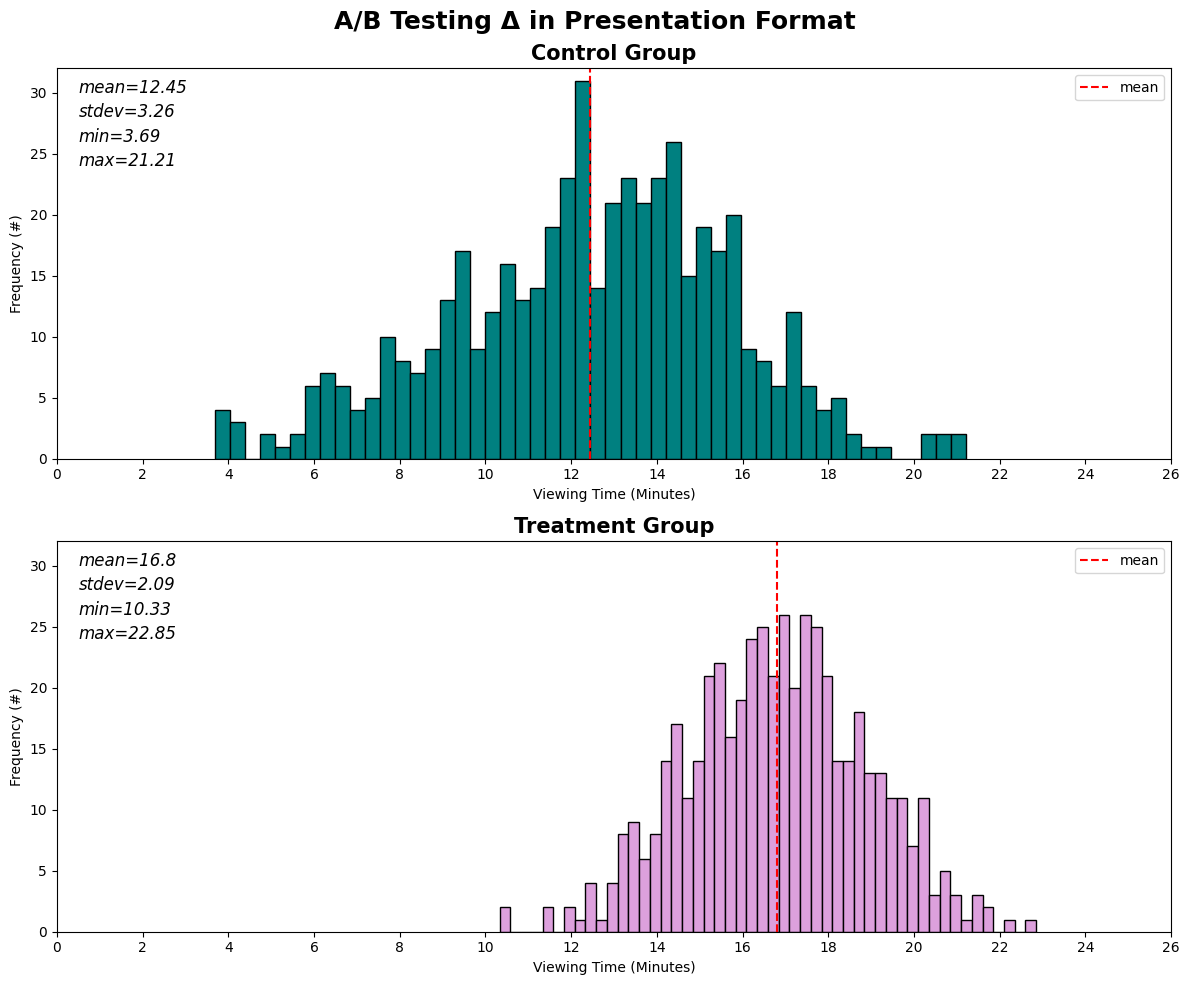

In [93]:
# TODO: create a data visualization to view differences in dispersion and mean
fig, axes = plt.subplots(2,1, figsize=(12,10))
plt.suptitle('A/B Testing Δ in Presentation Format', fontsize=18, weight='bold')

axes[0].hist(control_clean, bins=50, color='teal', edgecolor='black')
axes[0].set_title('Control Group', weight='bold', fontsize=15)
axes[0].set_xlim(0, 26)
axes[0].set_xticks(range(0, 27, 2))
axes[0].set_ylim(0, 32)
axes[0].set_xlabel('Viewing Time (Minutes)')
axes[0].set_ylabel('Frequency (#)')
axes[0].text(0.5, 30, f'mean={round(control_mean,2)}', fontsize=12, style='italic')
axes[0].text(0.5, 28, f'stdev={round(control_stdv,2)}', fontsize=12, style='italic')
axes[0].text(0.5, 26, f'min={min(control_clean)}', fontsize=12, style='italic')
axes[0].text(0.5, 24, f'max={max(control_clean)}', fontsize=12, style='italic')
axes[0].axvline(control_mean, color='red', linestyle='dashed', label='mean')
axes[0].legend(loc='best')

axes[1].hist(treatment_clean, bins=50, color='plum', edgecolor='black')
axes[1].set_title('Treatment Group', weight='bold', fontsize=15)
axes[1].set_xlim(0, 26)
axes[1].set_xticks(range(0, 27, 2))
axes[1].set_ylim(0, 32)
axes[1].set_xlabel('Viewing Time (Minutes)')
axes[1].set_ylabel('Frequency (#)')
axes[1].text(0.5, 30, f'mean={round(treatment_mean,2)}', fontsize=12, style='italic')
axes[1].text(0.5, 28, f'stdev={round(treatment_stdv,2)}', fontsize=12, style='italic')
axes[1].text(0.5, 26, f'min={min(treatment_clean)}', fontsize=12, style='italic')
axes[1].text(0.5, 24, f'max={max(treatment_clean)}', fontsize=12, style='italic')
axes[1].axvline(treatment_mean, color='red', linestyle='dashed', label='mean')
axes[1].legend(loc='best')

plt.tight_layout()
plt.show()

## 4. Your Data Findings

What did you discover about your two datasets? Which group has the highest viewing time? What would you want to investigate next?

did the averages differ from one dataset to another? Which dataset had the highest viewing time? What about the dispersion? What this tell you about viewing behaviors of both datasets.

***The control group viewed a presentation with 50 words/slide on average.*** 

***The treatment group viewed a presentation with 15 words/slide on average.*** 

There is a lot of nuance in these results:

Reducing the number of words/slide in the presentation has increased engagement, when comparing viewing averages of the treatment group (16.8 mins) vs. the control group (12.5 mins).

This seems counter-intuitive, however, measures of dispersion give us a fuller picture. The treatment group has a lower (2.1 mins) standard deviation in comparison to the control group (3.3 mins). Furthermore, the treatment group has a significantly smaller range (22.9 - 10.3) in comparison to the control group (21.2 - 3.7).

This suggests that the higher word count may have induced behaviors like skimming for brevity, whereas, the lower word count may have encouraged more thorough engageement with the educational content. 

With that being said, more research needs to be done to fully decode what the data is revealing here. What matters is that users truly learn from these educational presentations. Further tests on user performance on subsequent quizzes (e.g. # of failures before passing, exam scores, etc.) can reveal whether this change in presentation formatting is having a positive effect on measures of learning. With that data, we can develop a deeper understanding of these effects.